In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2, combine_pvalues
import seaborn as sns
from scipy.stats import ks_2samp


In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

### T_test to compare the means

In [3]:
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_claireNorm_PHASE1_mutants&WT_with_slopes.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')

/tmp/ipykernel_1597841/3503198913.py:2: DtypeWarning: Columns (463,464) have mixed types. Specify dtype option on import or set low_memory=False.
  new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_05_claireNorm_PHASE2_mutants&WT_with_slopes.csv')


In [6]:
def combine_pvalues_fisher(p_values):
    """Combines p-values using Fisher's method."""
    p_values = np.asarray(p_values)
    valid_p_values = p_values[~np.isnan(p_values)]
    if valid_p_values.size == 0:
        return np.nan  # Return NaN if all p-values are NaN
    combined_p = st.combine_pvalues(valid_p_values, method='fisher')[1]
    return combined_p

y2_cols = [col for col in data.columns if col.startswith('y2_') and 'std' not in col]
data['mean_y2'] = data[y2_cols].mean(axis=1)

p_values = []
for mutant in data['mutant_ID'].unique():
    mutant_data = data[data['mutant_ID'] == mutant]['mean_y2'].dropna()
    wt_data = data[data['mutant_ID'] == 'WT']['mean_y2'].dropna()
    if len(mutant_data) > 1 and len(wt_data) > 1:  # Ensure enough data for t-test
        t_stat, p_val = ttest_ind(mutant_data, wt_data)
        p_values.append({'mutant_ID': mutant, 'p_value': p_val})
    else:
        p_values.append({'mutant_ID': mutant, 'p_value': np.nan}) # Handle cases with insufficient data

p_value_df = pd.DataFrame(p_values)
data = data.merge(p_value_df, on='mutant_ID', how='left')

# Now you have individual p-values in the 'p_value' column
# You can proceed with Fisher's method as before
combined_p_values = data[~data['mutant_ID'].isin(['WT', 'WT CLiP'])].groupby(['mutant_ID', 'light_regime'])['p_value'].apply(combine_pvalues_fisher).reset_index(name='combined_p_value')
data = data.merge(combined_p_values, on=['mutant_ID', 'light_regime'], how='left')

/home/imokhtatif/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


           mutant_ID  combined_p_value
0  LMJ.RY0402.062562      2.555306e-08
1  LMJ.RY0402.063684      4.494842e-06
2  LMJ.RY0402.064876      1.233727e-07
3  LMJ.RY0402.059994      3.883651e-10
4  LMJ.RY0402.076021     1.373554e-270


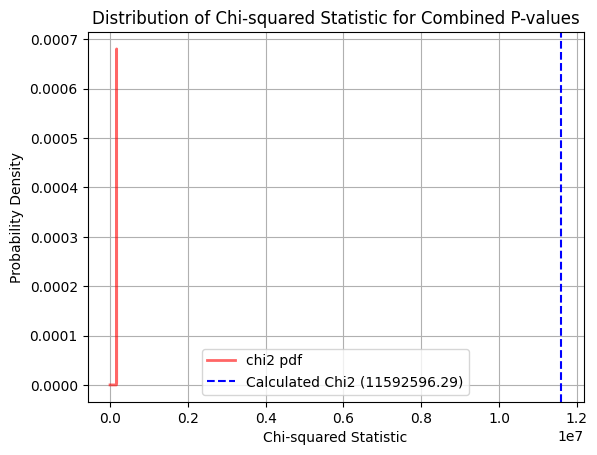

P-value from Chi-squared distribution: 0.000


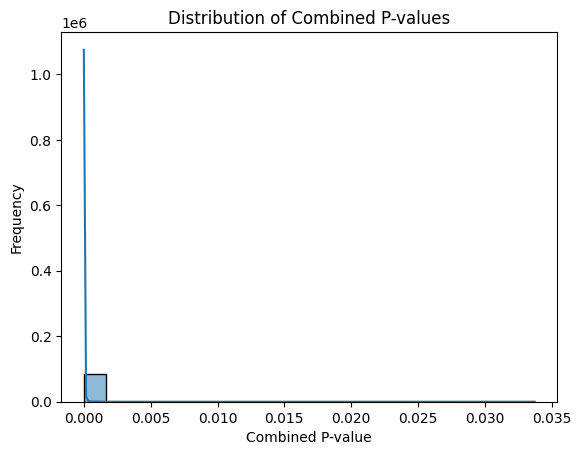

In [8]:
data = data[data['mutant_ID'] != 'WT']
data = data[data['mutant_ID'] != 'WT CLiP']
print(data[['mutant_ID', 'combined_p_value']].head())

combined_p_values = data['p_value'].dropna()
combined_p_values = combined_p_values[combined_p_values > 0]

chi2_stat = -2 * np.sum(np.log(combined_p_values))
df = 2 * len(combined_p_values)

p_val_chi2 = 1 - chi2.cdf(chi2_stat, df)

x = np.linspace(0, chi2.ppf(0.999, df), 100)
plt.plot(x, chi2.pdf(x, df), 'r-', lw=2, alpha=0.6, label='chi2 pdf')

plt.axvline(x=chi2_stat, color='b', linestyle='--', label=f'Calculated Chi2 ({chi2_stat:.2f})')

plt.title('Distribution of Chi-squared Statistic for Combined P-values')
plt.xlabel('Chi-squared Statistic')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

print(f"P-value from Chi-squared distribution: {p_val_chi2:.3f}")

plt.figure()
sns.histplot(combined_p_values, bins=20, kde=True)
plt.title('Distribution of Combined P-values')
plt.xlabel('Combined P-value')
plt.ylabel('Frequency')
plt.show()

In [60]:
data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean_combined_p_values.csv')

/tmp/ipykernel_1747685/152827193.py:1: DtypeWarning: Columns (1,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,372,373) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025_04_clean_combined_p_values.csv')


##### log-log plot of p-values

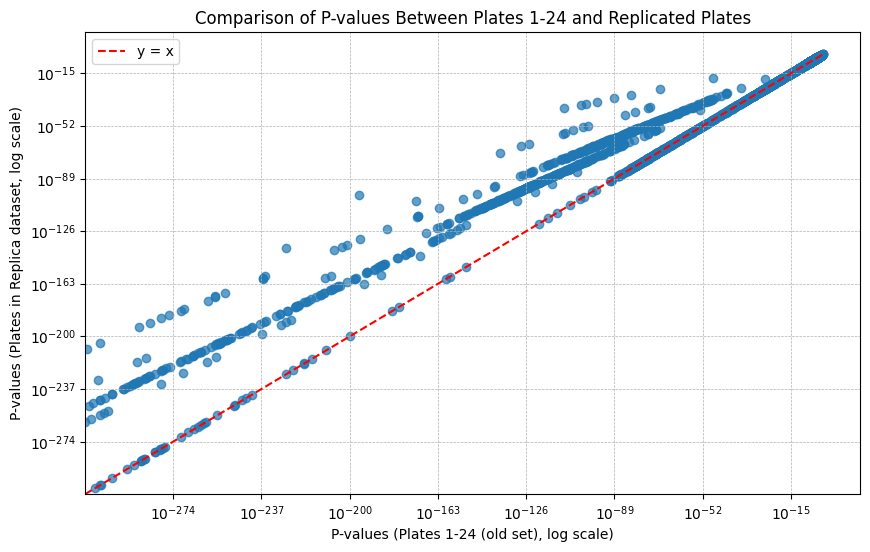

In [12]:
# Séparer les plaques numériques (1-24) et les plaques de type str (comme 33v1)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

plates_str = data[data['plate'].astype(str).str.contains(r'[a-zA-Z]') & data['plate']!='20']  # Plaques contenant des lettres

# Calculer les p-valeurs moyennes pour chaque mutant dans chaque sous-ensemble
p_values_numeric = plates_numeric.groupby('mutant_ID')['combined_p_value'].mean().reset_index(name='p_value_numeric')
p_values_str = plates_str.groupby('mutant_ID')['combined_p_value'].mean().reset_index(name='p_value_str')

# Fusionner les deux sous-ensembles sur les mutants
comparison = pd.merge(p_values_numeric, p_values_str, on='mutant_ID', how='inner')

# Filtrer les p-valeurs valides (supérieures à 0)
comparison = comparison[(comparison['p_value_numeric'] > 0) & (comparison['p_value_str'] > 0)]

# Tracer un graphique de comparaison (log-log)
plt.figure(figsize=(10, 6))
plt.scatter(comparison['p_value_numeric'], comparison['p_value_str'], alpha=0.7)
plt.xscale('log')  # Échelle logarithmique pour l'axe X
plt.yscale('log')  # Échelle logarithmique pour l'axe Y

# Tracer une ligne de référence y = x
min_val = min(comparison['p_value_numeric'].min(), comparison['p_value_str'].min())
max_val = max(comparison['p_value_numeric'].max(), comparison['p_value_str'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y = x')  # Ligne de référence

# Ajouter des détails au graphique
plt.title('Comparison of P-values Between Plates 1-24 and Replicated Plates')
plt.xlabel('P-values (Plates 1-24 (old set), log scale)')
# plt.xlim(0.05,1)
# plt.ylim(0.05,1)

plt.ylabel('P-values (Plates in Replica dataset, log scale)')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

#### Comparing all mutants

Nombre total de mutants significatifs dans les plaques numériques (1-24) : 7662
Nombre total de mutants significatifs dans les plaques répliquées : 1199
Nombre de mutants communs : 1195
Nombre de mutants significatifs uniquement dans les plaques numériques : 6467
Nombre de mutants significatifs uniquement dans les plaques répliquées : 4


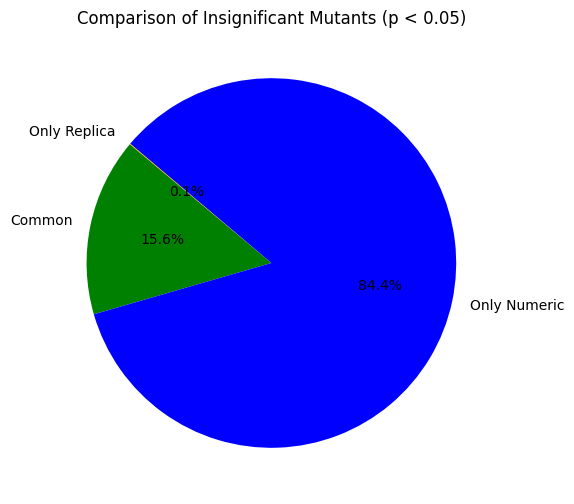

In [13]:
# Séparer les plaques numériques (1-24) et les plaques de type str (comme 33v1)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

#plates_str = data[data['plate'].astype(str).str.contains(r'[a-zA-Z]') & data['plate'] != '20']  # Plaques contenant des lettres
specified_plates = ['30v1', '30v2', '30v3','31v1', '31v2', '31v3','32v1', '32v2', '32v3', '33v1', '33v2', '33v3']  # Remplacez par les noms exacts des plaques que vous voulez inclure
plates_str = data[data['plate'].astype(str).isin(specified_plates)] 

# Identifier les mutants avec des p-valeurs significatives (<0.05) dans chaque partie
significant_numeric = plates_numeric[plates_numeric['combined_p_value'] < 0.05]['mutant_ID'].unique()
significant_str = plates_str[plates_str['combined_p_value'] < 0.05]['mutant_ID'].unique()

# Comparer les mutants significatifs
common_mutants = set(significant_numeric).intersection(significant_str)  # Mutants significatifs dans les deux parties
only_numeric = set(significant_numeric) - set(significant_str)  # Mutants significatifs uniquement dans les plaques numériques
only_str = set(significant_str) - set(significant_numeric)  # Mutants significatifs uniquement dans les plaques répliquées

# Résumé des résultats
print(f"Nombre total de mutants significatifs dans les plaques numériques (1-24) : {len(significant_numeric)}")
print(f"Nombre total de mutants significatifs dans les plaques répliquées : {len(significant_str)}")
print(f"Nombre de mutants communs : {len(common_mutants)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques numériques : {len(only_numeric)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques répliquées : {len(only_str)}")

# Visualisation des résultats
labels = ['Common', 'Only Numeric', 'Only Replica']
sizes = [len(common_mutants), len(only_numeric), len(only_str)]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Comparison of Insignificant Mutants (p < 0.05)')
plt.show()

##### Mean comparison only common mutants

Nombre total de mutants communs : 1195
Nombre total de mutants significatifs dans les plaques numériques (1-24) : 1195
Nombre total de mutants significatifs dans les plaques répliquées : 1195
Nombre de mutants significatifs communs : 1195
Nombre de mutants significatifs uniquement dans les plaques numériques : 0
Nombre de mutants significatifs uniquement dans les plaques répliquées : 0


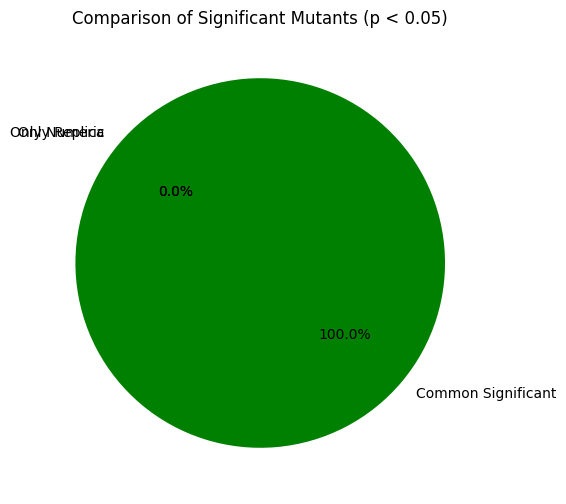

In [14]:

import pandas as pd
import matplotlib.pyplot as plt

# Séparer les plaques numériques (1-24)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

# Filtrer les plaques spécifiées
specified_plates = ['30v1', '30v2', '30v3', '31v1', '31v2', '31v3', '32v1', '32v2', '32v3', '33v1', '33v2', '33v3']
plates_str = data[data['plate'].astype(str).isin(specified_plates)]  # Filtrer uniquement les plaques spécifiées

# Identifier les mutants présents dans les deux ensembles
mutants_numeric = set(plates_numeric['mutant_ID'].unique())
mutants_str = set(plates_str['mutant_ID'].unique())
common_mutants = mutants_numeric.intersection(mutants_str)  # Mutants présents dans les deux ensembles

# Filtrer les données pour ne conserver que les mutants communs
plates_numeric_common = plates_numeric[plates_numeric['mutant_ID'].isin(common_mutants)]
plates_str_common = plates_str[plates_str['mutant_ID'].isin(common_mutants)]

# Identifier les mutants significatifs (<0.05) dans chaque partie
significant_numeric = plates_numeric_common[plates_numeric_common['combined_p_value'] < 0.05]['mutant_ID'].unique()
significant_str = plates_str_common[plates_str_common['combined_p_value'] < 0.05]['mutant_ID'].unique()

# Comparer les mutants significatifs
common_significant_mutants = set(significant_numeric).intersection(significant_str)  # Mutants significatifs communs
only_numeric = set(significant_numeric) - set(significant_str)  # Mutants significatifs uniquement dans les plaques numériques
only_str = set(significant_str) - set(significant_numeric)  # Mutants significatifs uniquement dans les plaques répliquées

# Résumé des résultats
print(f"Nombre total de mutants communs : {len(common_mutants)}")
print(f"Nombre total de mutants significatifs dans les plaques numériques (1-24) : {len(significant_numeric)}")
print(f"Nombre total de mutants significatifs dans les plaques répliquées : {len(significant_str)}")
print(f"Nombre de mutants significatifs communs : {len(common_significant_mutants)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques numériques : {len(only_numeric)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques répliquées : {len(only_str)}")

# Visualisation des résultats
labels = ['Common Significant', 'Only Numeric', 'Only Replica']
sizes = [len(common_significant_mutants), len(only_numeric), len(only_str)]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Comparison of Significant Mutants (p < 0.05)')
plt.show()

## slope KS test p values

In [3]:
# Charger le fichier .pkl
file_path = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_slopes_new30data.pkl'  # Remplacez par le chemin réel de votre fichier
data_rep = pd.read_pickle(file_path)

data_num = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv')

/tmp/ipykernel_1843133/2668856443.py:5: DtypeWarning: Columns (381,382) have mixed types. Specify dtype option on import or set low_memory=False.
  data_num = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv')


In [ ]:

# Charger les fichiers
file_path_rep = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_slopes_new30data.pkl'
data_rep = pd.read_pickle(file_path_rep)

file_path_num = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv'
data_num = pd.read_csv(file_path_num)

# Combiner les deux datasets si nécessaire
data_combined = pd.concat([data_rep, data_num], ignore_index=True)

# S'assurer que 'mutant_ID' est de type chaîne et gérer les NaN
data_combined['mutant_ID'] = data_combined['mutant_ID'].fillna('').astype(str)

# Ajouter une colonne pour les p-valeurs
data_combined['p_value_ks'] = None

# Identifier les régimes lumineux et les plaques uniques
light_regimes = data_combined['light_regime'].unique()
plates = data_combined['plate'].unique()

# Effectuer le test KS pour chaque combinaison de régime lumineux et plaque
for regime in light_regimes:
    for plate in plates:
        # Filtrer les données pour le régime lumineux et la plaque
        subset = data_combined[(data_combined['light_regime'] == regime) & (data_combined['plate'] == plate)]
        
        # Séparer les données WT et mutants
        wt_data = subset[subset['mutant_ID'].str.contains('WT')]['slope_y2']
        mutant_data = subset[~subset['mutant_ID'].str.contains('WT')]['slope_y2']
        
        # Vérifier qu'il y a des données suffisantes pour effectuer le test
        if len(wt_data) > 1 and len(mutant_data) > 1:
            # Effectuer le test KS
            ks_stat, p_value = ks_2samp(wt_data, mutant_data)
            
            # Ajouter la p-valeur aux lignes correspondantes
            data_combined.loc[
                (data_combined['light_regime'] == regime) & 
                (data_combined['plate'] == plate) & 
                ~data_combined['mutant_ID'].str.contains('WT'), 
                'p_value_ks'
            ] = p_value

# Sauvegarder le dataset avec les p-valeurs ajoutées
output_path = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_with_slope_p_values_fisher.pkl'
data_combined.to_pickle(output_path)

print(f"Les p-valeurs ont été calculées et ajoutées. Le fichier mis à jour a été sauvegardé à : {output_path}")

/tmp/ipykernel_1747685/2214253157.py:9: DtypeWarning: Columns (381,382) have mixed types. Specify dtype option on import or set low_memory=False.
  data_num = pd.read_csv(file_path_num)
/tmp/ipykernel_1747685/2214253157.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_combined['p_value_ks'] = None


Les p-valeurs ont été calculées et ajoutées. Le fichier mis à jour a été sauvegardé à : /home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_with_slope_p_values_fisher.pkl


In [ ]:

# Convertir la colonne 'p_value_ks' en type float pour s'assurer qu'elle est numérique
data_combined['p_value_ks'] = pd.to_numeric(data_combined['p_value_ks'], errors='coerce')

# Fonction pour combiner les p-valeurs avec la méthode de Fisher
def combine_pvalues_fisher(p_values):
    """Combine les p-valeurs en utilisant la méthode de Fisher."""
    p_values = np.asarray(p_values)
    valid_p_values = p_values[~np.isnan(p_values)]  # Exclure les NaN
    if valid_p_values.size == 0:
        return np.nan  # Retourner NaN si toutes les p-valeurs sont NaN
    combined_p = combine_pvalues(valid_p_values, method='fisher')[1]
    return combined_p

# Appliquer la méthode de Fisher pour combiner les p-valeurs par mutant et régime lumineux
combined_p_values = (
    data_combined[~data_combined['mutant_ID'].str.contains('WT', na=False)]
    .groupby(['mutant_ID', 'light_regime'])['p_value_ks']
    .apply(combine_pvalues_fisher)
    .reset_index(name='combined_p_value')
)

# Fusionner les p-valeurs combinées avec le DataFrame original
data_combined = data_combined.merge(combined_p_values, on=['mutant_ID', 'light_regime'], how='left')

# Sauvegarder le DataFrame mis à jour
output_path = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_with_slope_p_values_fisher.pkl'
data_combined.to_pickle(output_path)

print(f"Les p-valeurs combinées ont été ajoutées. Le fichier mis à jour a été sauvegardé à : {output_path}")

Les p-valeurs combinées ont été ajoutées. Le fichier mis à jour a été sauvegardé à : /home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Notebooks/data_with_slope_p_values_fisher.pkl


In [40]:
data['plate'].unique()

array(['30v1', '30v2', '30v3', '31v1', '32v1', '31v2', '32v2', '31v3',
       '32v3', '33v1', '33v2', '33v3', '99', 99, 2, 3, 4, 5, 6, 7, 9, 10,
       11, 12, 13, 14, 15, 16, 8, 18, 17, 21, 22, 23, 1, 20, 24],
      dtype=object)

### ALL mutants even the non replicated

Nombre total de mutants significatifs dans les plaques numériques (1-24) : 6915
Nombre total de mutants significatifs dans les plaques répliquées : 1197
Nombre de mutants communs : 1191
Nombre de mutants significatifs uniquement dans les plaques numériques : 5724
Nombre de mutants significatifs uniquement dans les plaques répliquées : 6


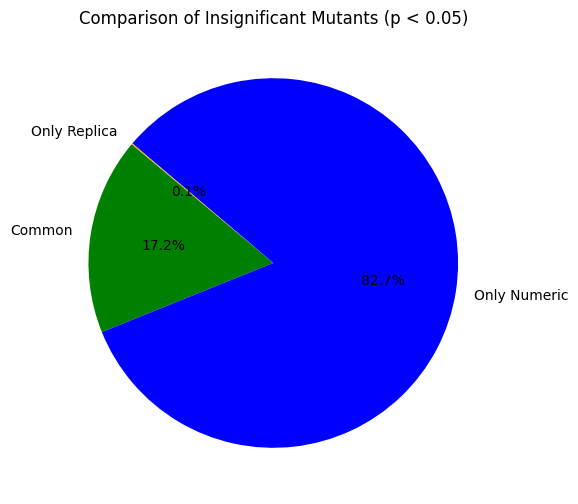

In [ ]:

data = data_combined

# Séparer les plaques numériques (1-24) et les plaques de type str (comme 33v1)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

#plates_str = data[data['plate'].astype(str).str.contains(r'[a-zA-Z]') & data['plate'] != '20']  # Plaques contenant des lettres
specified_plates = ['30v1', '30v2', '30v3','31v1', '31v2', '31v3','32v1', '32v2', '32v3', '33v1', '33v2', '33v3']  # Remplacez par les noms exacts des plaques que vous voulez inclure
plates_str = data[data['plate'].astype(str).isin(specified_plates)] 

# Identifier les mutants avec des p-valeurs significatives (<0.05) dans chaque partie
significant_numeric = plates_numeric[plates_numeric['combined_p_value'] < 0.05]['mutant_ID'].unique()
significant_str = plates_str[plates_str['combined_p_value'] < 0.05]['mutant_ID'].unique()

# Comparer les mutants significatifs
common_mutants = set(significant_numeric).intersection(significant_str)  # Mutants significatifs dans les deux parties
only_numeric = set(significant_numeric) - set(significant_str)  # Mutants significatifs uniquement dans les plaques numériques
only_str = set(significant_str) - set(significant_numeric)  # Mutants significatifs uniquement dans les plaques répliquées

# Résumé des résultats
print(f"Nombre total de mutants significatifs dans les plaques numériques (1-24) : {len(significant_numeric)}")
print(f"Nombre total de mutants significatifs dans les plaques répliquées : {len(significant_str)}")
print(f"Nombre de mutants communs : {len(common_mutants)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques numériques : {len(only_numeric)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques répliquées : {len(only_str)}")

# Visualisation des résultats
labels = ['Common', 'Only Numeric', 'Only Replica']
sizes = [len(common_mutants), len(only_numeric), len(only_str)]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Comparison of Insignificant Mutants (p < 0.05)')
plt.show()

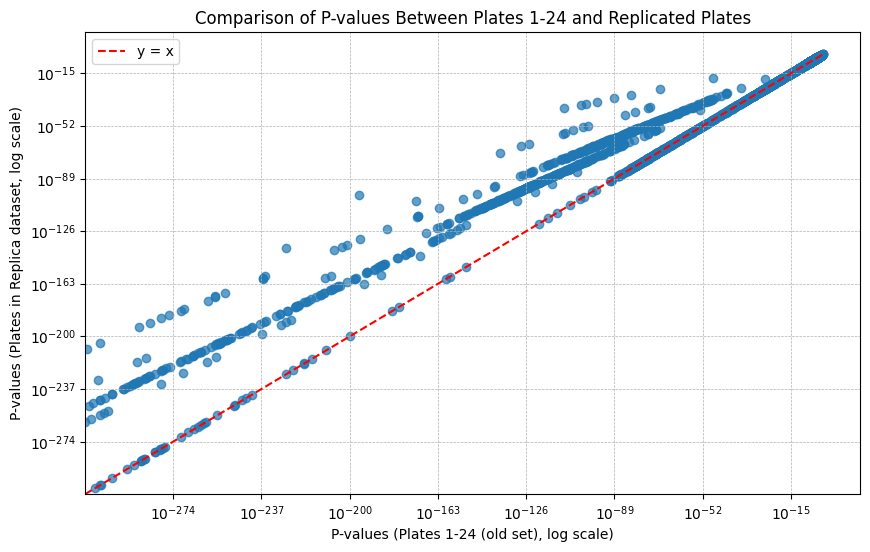

In [15]:
# Séparer les plaques numériques (1-24) et les plaques de type str (comme 33v1)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

plates_str = data[data['plate'].astype(str).str.contains(r'[a-zA-Z]') & data['plate']!='20']  # Plaques contenant des lettres

# Calculer les p-valeurs moyennes pour chaque mutant dans chaque sous-ensemble
p_values_numeric = plates_numeric.groupby('mutant_ID')['combined_p_value'].mean().reset_index(name='p_value_numeric')
p_values_str = plates_str.groupby('mutant_ID')['combined_p_value'].mean().reset_index(name='p_value_str')

# Fusionner les deux sous-ensembles sur les mutants
comparison = pd.merge(p_values_numeric, p_values_str, on='mutant_ID', how='inner')

# Filtrer les p-valeurs valides (supérieures à 0)
comparison = comparison[(comparison['p_value_numeric'] > 0) & (comparison['p_value_str'] > 0)]

# Tracer un graphique de comparaison (log-log)
plt.figure(figsize=(10, 6))
plt.scatter(comparison['p_value_numeric'], comparison['p_value_str'], alpha=0.7)
plt.xscale('log')  # Échelle logarithmique pour l'axe X
plt.yscale('log')  # Échelle logarithmique pour l'axe Y

# Tracer une ligne de référence y = x
min_val = min(comparison['p_value_numeric'].min(), comparison['p_value_str'].min())
max_val = max(comparison['p_value_numeric'].max(), comparison['p_value_str'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y = x')  # Ligne de référence

# Ajouter des détails au graphique
plt.title('Comparison of P-values Between Plates 1-24 and Replicated Plates')
plt.xlabel('P-values (Plates 1-24 (old set), log scale)')
# plt.xlim(0.05,1)
# plt.ylim(0.05,1)

plt.ylabel('P-values (Plates in Replica dataset, log scale)')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [67]:
import pandas as pd

# Obtenir les mutants significatifs et leurs gènes mutés pour les plaques numériques
significant_numeric_data = plates_numeric[plates_numeric['combined_p_value'] < 0.05][['mutant_ID', 'mutated_genes']].drop_duplicates()

# Obtenir les mutants significatifs et leurs gènes mutés pour les plaques de type chaîne
significant_str_data = plates_str[plates_str['combined_p_value'] < 0.05][['mutant_ID', 'mutated_genes']].drop_duplicates()

# Convertir en ensembles pour comparer les mutants
significant_numeric_set = set(significant_numeric_data['mutant_ID'])
significant_str_set = set(significant_str_data['mutant_ID'])

# Comparer les mutants
common_mutants = significant_numeric_set.intersection(significant_str_set)
only_numeric = significant_numeric_set - significant_str_set
only_str = significant_str_set - significant_numeric_set

# Afficher les résultats
print("Mutants significatifs uniques et leurs gènes mutés (plaques numériques) :")
print(significant_numeric_data)

print("\nMutants significatifs uniques et leurs gènes mutés (plaques de type chaîne) :")
print(significant_str_data)

print("\nMutants communs entre les deux ensembles :")
print(significant_numeric_data[significant_numeric_data['mutant_ID'].isin(common_mutants)])

print("\nMutants significatifs uniquement dans les plaques numériques :")
print(significant_numeric_data[significant_numeric_data['mutant_ID'].isin(only_numeric)])

print("\nMutants significatifs uniquement dans les plaques de type chaîne :")
print(significant_str_data[significant_str_data['mutant_ID'].isin(only_str)])

Mutants significatifs uniques et leurs gènes mutés (plaques numériques) :
               mutant_ID   mutated_genes
41023  LMJ.RY0402.061332   Cre01.g011901
41024  LMJ.RY0402.071251   Cre11.g479350
41025  LMJ.RY0402.071251   Cre07.g343933
41028  LMJ.RY0402.062549   Cre09.g394251
41030  LMJ.RY0402.064533   Cre12.g528300
...                  ...             ...
92748             lcr1-2  special_mutant
92750             bsti-1  special_mutant
92751                dm3  special_mutant
92777            mdh5-62  special_mutant
92834          NK1NK2-14  special_mutant

[7968 rows x 2 columns]

Mutants significatifs uniques et leurs gènes mutés (plaques de type chaîne) :
               mutant_ID  mutated_genes
0      LMJ.RY0402.052440  Cre01.g028650
1      LMJ.RY0402.047311  Cre08.g375800
2      LMJ.RY0402.047311  Cre01.g049900
3      LMJ.RY0402.047311  Cre01.g049950
5      LMJ.RY0402.054897  Cre02.g095115
...                  ...            ...
24724  LMJ.RY0402.224627  Cre16.g662951
24729  LMJ

### Only the replicated

Nombre total de mutants communs : 1194
Nombre total de mutants significatifs dans les plaques numériques (1-24) : 1191
Nombre total de mutants significatifs dans les plaques répliquées : 1193
Nombre de mutants significatifs communs : 1191
Nombre de mutants significatifs uniquement dans les plaques numériques : 0
Nombre de mutants significatifs uniquement dans les plaques répliquées : 2


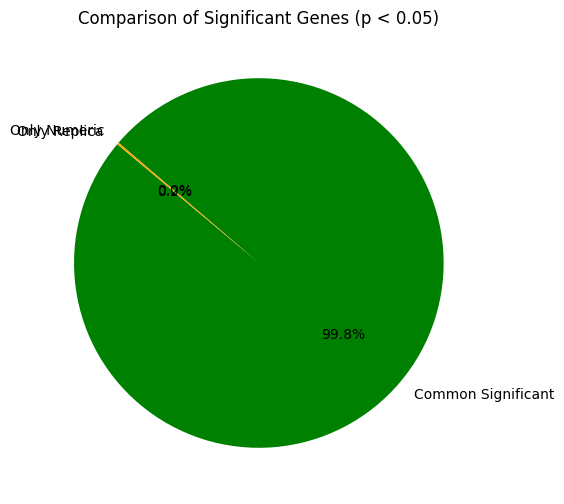

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
data = data_combined

# Séparer les plaques numériques (1-24)
plates_numeric = data[data['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

# Filtrer les plaques spécifiées
specified_plates = ['30v1', '30v2', '30v3', '31v1', '31v2', '31v3', '32v1', '32v2', '32v3', '33v1', '33v2', '33v3']
plates_str = data[data['plate'].astype(str).isin(specified_plates)]  # Filtrer uniquement les plaques spécifiées

# Identifier les mutants présents dans les deux ensembles
mutants_numeric = set(plates_numeric['mutant_ID'].unique())
mutants_str = set(plates_str['mutant_ID'].unique())
common_mutants = mutants_numeric.intersection(mutants_str)  # Mutants présents dans les deux ensembles

# Filtrer les données pour ne conserver que les mutants communs
plates_numeric_common = plates_numeric[plates_numeric['mutant_ID'].isin(common_mutants)]
plates_str_common = plates_str[plates_str['mutant_ID'].isin(common_mutants)]

# Identifier les mutants significatifs (<0.05) dans chaque partie
significant_numeric = plates_numeric_common[plates_numeric_common['combined_p_value'] < 0.05]['mutant_ID'].unique()
significant_str = plates_str_common[plates_str_common['combined_p_value'] < 0.05]['mutant_ID'].unique()

# Comparer les mutants significatifs
common_significant_mutants = set(significant_numeric).intersection(significant_str)  # Mutants significatifs communs
only_numeric = set(significant_numeric) - set(significant_str)  # Mutants significatifs uniquement dans les plaques numériques
only_str = set(significant_str) - set(significant_numeric)  # Mutants significatifs uniquement dans les plaques répliquées

# Résumé des résultats
print(f"Nombre total de mutants communs : {len(common_mutants)}")
print(f"Nombre total de mutants significatifs dans les plaques numériques (1-24) : {len(significant_numeric)}")
print(f"Nombre total de mutants significatifs dans les plaques répliquées : {len(significant_str)}")
print(f"Nombre de mutants significatifs communs : {len(common_significant_mutants)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques numériques : {len(only_numeric)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques répliquées : {len(only_str)}")

# Visualisation des résultats
labels = ['Common Significant', 'Only Numeric', 'Only Replica']
sizes = [len(common_significant_mutants), len(only_numeric), len(only_str)]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Comparison of Significant Genes (p < 0.05)')
plt.show()

## Back to Samson's outlier detect

In [8]:
from Scripts import Outlier_detection_v2

In [16]:
data_rep = new
data_num = old

In [17]:
data_rep_cluster = Outlier_detection_v2.detect_and_cluster_slopes(data_rep, alpha=0.05)
data_num_cluster = Outlier_detection_v2.detect_and_cluster_slopes(data_num, alpha=0.05)


Nombre total de mutants communs : 651
Nombre total de mutants significatifs dans les plaques numériques (1-24) : 608
Nombre total de mutants significatifs dans les plaques répliquées : 650
Nombre de mutants significatifs communs : 607
Nombre de mutants significatifs uniquement dans les plaques numériques : 1
Nombre de mutants significatifs uniquement dans les plaques répliquées : 43


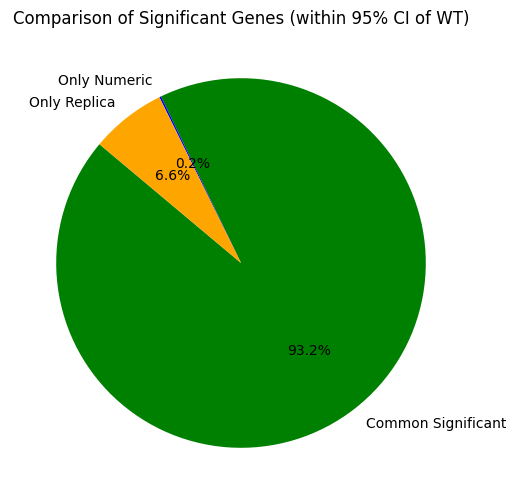

In [21]:
# Séparer les plaques numériques (1-24)
plates_numeric = data_num_cluster[data_num_cluster['plate'].astype(str).str.match(r'^\d+$')]  # Plaques contenant uniquement des chiffres
plates_numeric = plates_numeric[plates_numeric['plate'].astype(int) <= 24]  # Filtrer les plaques numériques <= 24

# Filtrer les plaques spécifiées
specified_plates = ['30v1', '30v2', '30v3', '31v1', '31v2', '31v3', '32v1', '32v2', '32v3', '33v1', '33v2', '33v3']
plates_str = data_rep_cluster[data_rep_cluster['plate'].astype(str).isin(specified_plates)]  # Filtrer uniquement les plaques spécifiées

# Identifier les mutants présents dans les deux ensembles
mutants_numeric = set(plates_numeric['mutated_genes'].unique())
mutants_str = set(plates_str['mutated_genes'].unique())
common_mutants = mutants_numeric.intersection(mutants_str)  # Mutants présents dans les deux ensembles

# Filtrer les données pour ne conserver que les mutants communs
plates_numeric_common = plates_numeric[plates_numeric['mutated_genes'].isin(common_mutants)]
plates_str_common = plates_str[plates_str['mutated_genes'].isin(common_mutants)]

# Identifier les mutants significatifs (<0.05) dans chaque partie
significant_numeric = plates_numeric_common[plates_numeric_common['slope_cluster_y2'] !=0]['mutated_genes'].unique()
significant_str = plates_str_common[plates_str_common['slope_cluster_y2'] !=0]['mutated_genes'].unique()

# Comparer les mutants significatifs
common_significant_mutants = set(significant_numeric).intersection(significant_str)  # Mutants significatifs communs
only_numeric = set(significant_numeric) - set(significant_str)  # Mutants significatifs uniquement dans les plaques numériques
only_str = set(significant_str) - set(significant_numeric)  # Mutants significatifs uniquement dans les plaques répliquées

# Résumé des résultats
print(f"Nombre total de mutants communs : {len(common_mutants)}")
print(f"Nombre total de mutants significatifs dans les plaques numériques (1-24) : {len(significant_numeric)}")
print(f"Nombre total de mutants significatifs dans les plaques répliquées : {len(significant_str)}")
print(f"Nombre de mutants significatifs communs : {len(common_significant_mutants)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques numériques : {len(only_numeric)}")
print(f"Nombre de mutants significatifs uniquement dans les plaques répliquées : {len(only_str)}")

# Visualisation des résultats
labels = ['Common Significant', 'Only Numeric', 'Only Replica']
sizes = [len(common_significant_mutants), len(only_numeric), len(only_str)]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Comparison of Significant Genes (within 95% CI of WT)')
plt.show()

/tmp/ipykernel_1468867/3888575679.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


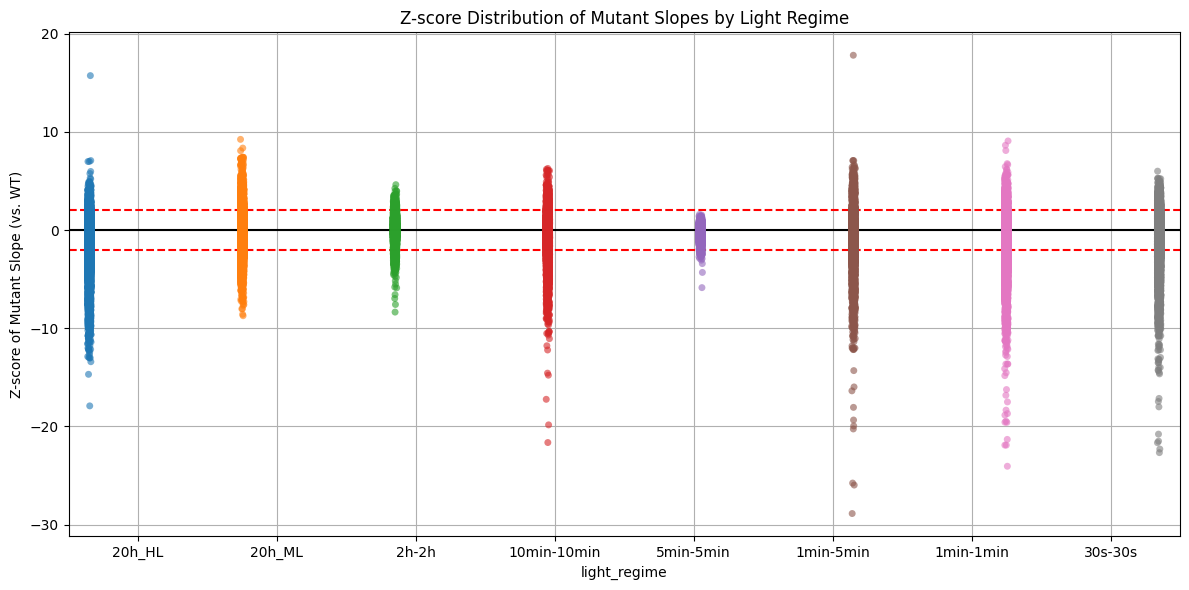

In [21]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.stripplot(data=df_z, x='light_regime', y='z_score', hue='light_regime', jitter=True, dodge=True, alpha=0.6)
plt.axhline(0, color='black')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.ylabel("Z-score of Mutant Slope (vs. WT)")
plt.title("Z-score Distribution of Mutant Slopes by Light Regime")
plt.legend().remove()
plt.grid(True)
plt.tight_layout()
plt.show()


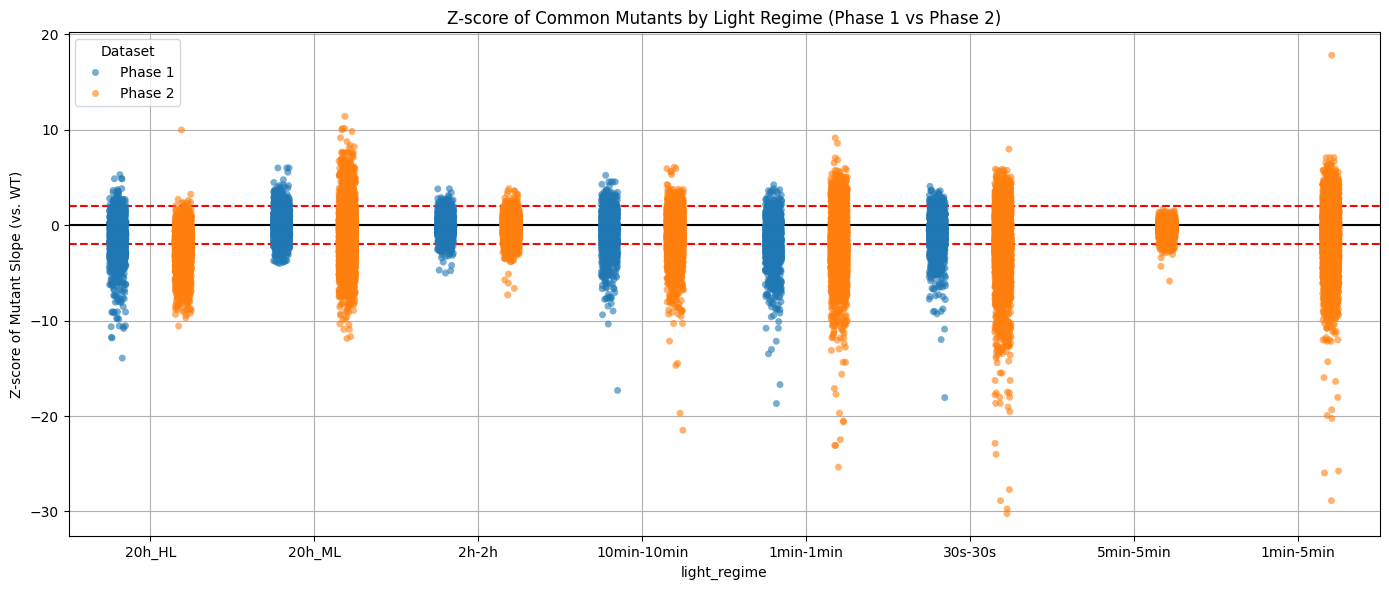

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get common mutant_IDs
common_mutants = set(old['mutant_ID'].unique()) & set(new['mutant_ID'].unique())
common_mutants -= {'WT', 'WT CLiP'}

def compute_z_scores(data, label, common_mutants):
    wt_data = data[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data['nullWT'] == True)]
    mutant_data = data[data['mutant_ID'].isin(common_mutants)]

    results = []
    light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
    for regime in light_regimes:
        wt_slopes = wt_data[wt_data['light_regime'] == regime]['y2_slope'].dropna()
        if len(wt_slopes) < 3:
            continue
        wt_mean = wt_slopes.mean()
        wt_std = wt_slopes.std()

        subset = mutant_data[mutant_data['light_regime'] == regime]
        for _, row in subset.iterrows():
            z_score = (row['y2_slope'] - wt_mean) / wt_std
            results.append({
                'mutant_ID': row['mutant_ID'],
                'light_regime': regime,
                'y2_slope': row['y2_slope'],
                'z_score': z_score,
                'dataset': label
            })

    return pd.DataFrame(results)

# Compute z-scores only for shared mutants
df1 = compute_z_scores(old, 'Phase 1', common_mutants)
df2 = compute_z_scores(new, 'Phase 2', common_mutants)

df_combined = pd.concat([df1, df2], ignore_index=True)

# Plot
plt.figure(figsize=(14, 6))
sns.stripplot(
    data=df_combined,
    x='light_regime',
    y='z_score',
    hue='dataset',
    jitter=True,
    dodge=True,
    alpha=0.6
)

plt.axhline(0, color='black')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.ylabel("Z-score of Mutant Slope (vs. WT)")
plt.title("Z-score of Common Mutants by Light Regime (Phase 1 vs Phase 2)")
plt.grid(True)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()


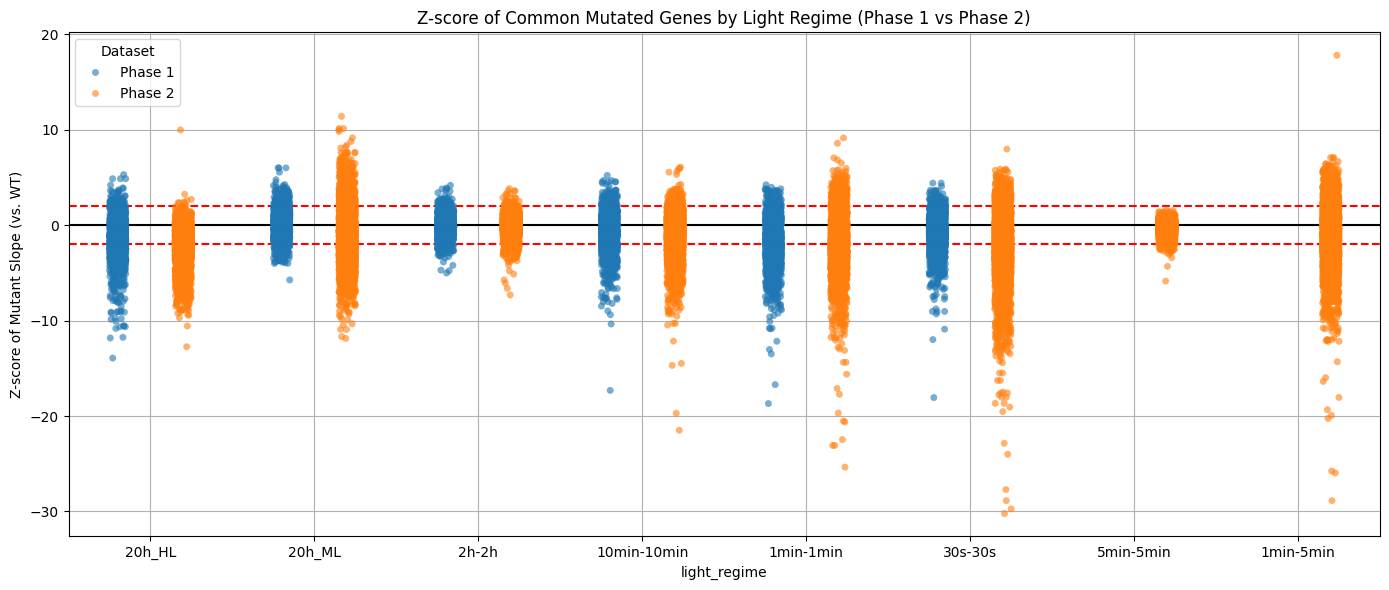

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get common mutated_genes
common_genes = set(old['mutated_genes'].dropna().unique()) & set(new['mutated_genes'].dropna().unique())

def compute_z_scores(data, label, common_genes):
    wt_data = data[(data['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data['nullWT'] == True)]
    mutant_data = data[data['mutated_genes'].isin(common_genes)]

    results = []
    light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
    for regime in light_regimes:
        wt_slopes = wt_data[wt_data['light_regime'] == regime]['y2_slope'].dropna()
        if len(wt_slopes) < 3:
            continue
        wt_mean = wt_slopes.mean()
        wt_std = wt_slopes.std()

        subset = mutant_data[mutant_data['light_regime'] == regime]
        for _, row in subset.iterrows():
            z_score = (row['y2_slope'] - wt_mean) / wt_std
            results.append({
                'mutated_genes': row['mutated_genes'],
                'light_regime': regime,
                'y2_slope': row['y2_slope'],
                'z_score': z_score,
                'dataset': label
            })

    return pd.DataFrame(results)

# Compute z-scores only for shared mutated genes
df1 = compute_z_scores(old, 'Phase 1', common_genes)
df2 = compute_z_scores(new, 'Phase 2', common_genes)

df_combined = pd.concat([df1, df2], ignore_index=True)

# Plot
plt.figure(figsize=(14, 6))
sns.stripplot(
    data=df_combined,
    x='light_regime',
    y='z_score',
    hue='dataset',
    jitter=True,
    dodge=True,
    alpha=0.6
)

plt.axhline(0, color='black')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.ylabel("Z-score of Mutant Slope (vs. WT)")
plt.title("Z-score of Common Mutated Genes by Light Regime (Phase 1 vs Phase 2)")
plt.grid(True)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()
